<a href="https://colab.research.google.com/github/DiegoAbarza77/Deep_Learning/blob/Desarrollo/EvaluacionParcial_1_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial 1: Fundamentos de Deep Learning
**Estudiante:** Diego Abarza  
**Asignatura:** Deep Learning   
**Proyecto:** Clasificación de imágenes con Red Neuronal Artificial (MLP) utilizando Fashion-MNIST.

## 1. Contexto y Objetivos
El objetivo de este proyecto es implementar una red neuronal de tipo **Perceptrón Multicapa (MLP)** para clasificar artículos de ropa en 10 categorías. Se aplicarán técnicas de preprocesamiento, normalización y optimización de hiperparámetros.

# *2. Preprocesamiento*, donde cargamos los datos, hacemos la limpieza y adaptacion






In [ ]:
# --- PASO 1: Importación de librerías ---
from tensorflow import keras
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from keras import regularizers


# --- PASO 2: Carga del dataset Fashion-MNIST ---
# Cargamos los datos de entrenamiento (60k) y prueba (10k)
(imgs_train, labs_train), (imgs_test, labs_test) = keras.datasets.fashion_mnist.load_data()

# Verificamos las dimensiones de los datos cargados
print("Imágenes de entrenamiento:", imgs_train.shape) # Salida esperada: (60000, 28, 28)
print("Imágenes de prueba:", imgs_test.shape)        # Salida esperada: (10000, 28, 28)

# --- PASO 3: Definición de etiquetas ---
# Estas son las 10 clases que el modelo deberá aprender a distinguir
nombres = ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo',
           'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']



Imágenes de entrenamiento: (60000, 28, 28)
Imágenes de prueba: (10000, 28, 28)


# Verificación de datos

Verificación de Datos: "Se visualiza una muestra aleatoria de imágenes para verificar la correcta carga del dataset y la correspondencia entre las imágenes y sus etiquetas (nombres)."

Observación Técnica: "Se confirma que las imágenes poseen una resolución de 28x28 píxeles y se presentan en escala de grises. Esto implica que cada dato de entrada para nuestra futura red neuronal será una matriz de valores entre 0 y 255."

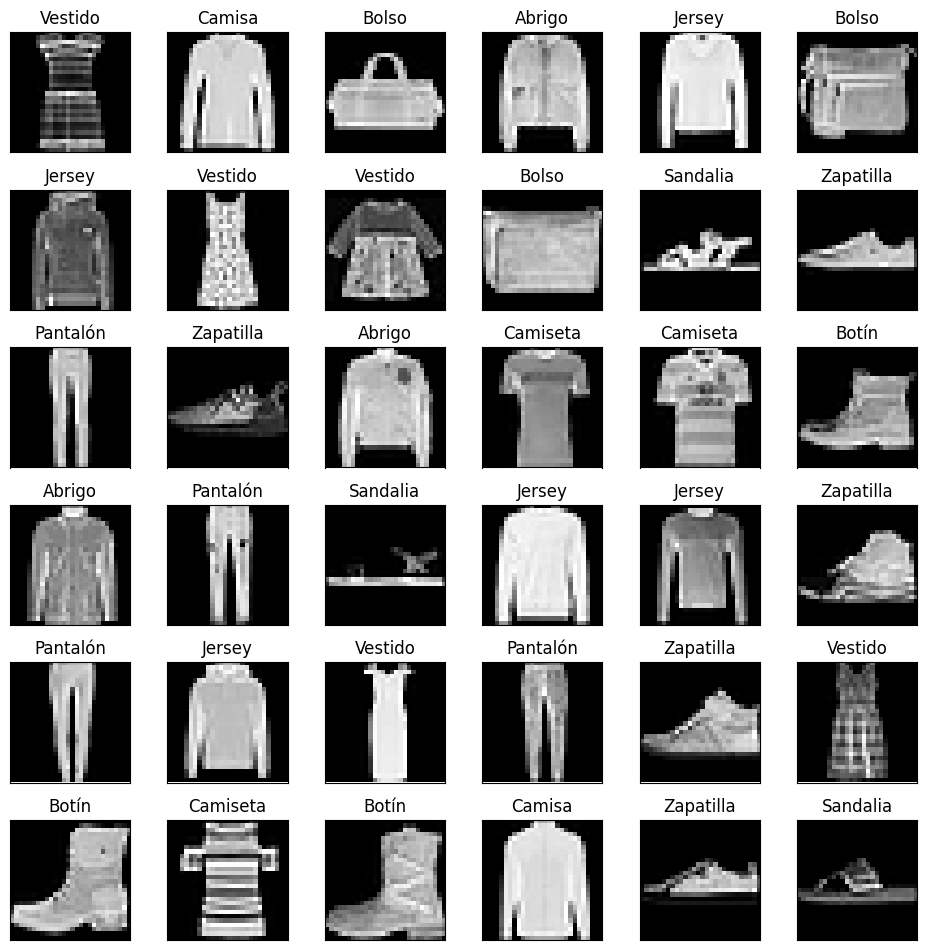

In [ ]:
# Definimos las dimensiones de la grilla para mostrar 12 ejemplos
h = 6 # filas
w = 6 # columnas

fig, axs = plt.subplots(h, w, figsize=(1.6*w, 1.6*h))

for i in range(h):
    for j in range(w):
        # Seleccionamos un índice al azar
        ex = np.random.randint(len(imgs_test))

        # Mostramos el nombre de la categoría
        # Nota: en Fashion-MNIST labs_test[ex] es un escalar, no una lista
        axs[i,j].set_title(nombres[labs_test[ex]])

        # Configuramos la estética de la imagen
        axs[i,j].grid(False)
        axs[i,j].set_xticks([])
        axs[i,j].set_yticks([])

        # Mostramos la imagen en escala de grises (cmap='gray')
        axs[i,j].imshow(imgs_test[ex], cmap='gray')

plt.tight_layout()
plt.show()

##Preprocesamiento Técnico
Para que la red MLP pueda procesar los datos, realizamos las siguientes transformaciones:
1. Convertimos la matriz de $28 \times 28$ en un vector de $784$ neuronas.
2. Escalamos los valores de los píxeles al rango $[0, 1]$.
3. Transformamos las etiquetas en vectores categóricos para usar la pérdida `categorical_crossentropy`.

In [ ]:
# Transformación de datos

# Reshape: Aplanamos las imágenes (28x28 = 784)
X_train = imgs_train.reshape(60000, 28*28).astype('float32')
X_test = imgs_test.reshape(10000, 28*28).astype('float32')

# Normalización
X_train /= 255
X_test /= 255
print('X', X_train.shape, X_test.shape)

# One Hot Encoding
Y_train = keras.utils.to_categorical(labs_train, 10)
Y_test = keras.utils.to_categorical(labs_test, 10)
print('Y', Y_train.shape, Y_test.shape)

X (60000, 784) (10000, 784)
Y (60000, 10) (10000, 10)


In [ ]:
# cantidad de ejemplos (train/test), neuronas de entrada y neuronas de salida
M_train = X_train.shape[0]
M_test = X_test.shape[0]

N = X_train.shape[1]
C = Y_train.shape[1]

print(f"Entradas (N): {N}, Clases (C): {C}")

Entradas (N): 784, Clases (C): 10


## Arquitectura de la Red Neuronal
Implementamos una red secuencial con las siguientes capas:
* **Capas Ocultas:** 512 y 256 neuronas con activación `ReLU`.
* **Capa de Salida:** 10 neuronas con activación `Softmax`.
* **Optimizador:** Descenso de Gradiente Estocástico (`SGD`).

#1.  Una red normal y regular SGD

In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

In [ ]:
# Creación de la Red ---
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

red = keras.Sequential()
red.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dense(h2, activation='relu'))
red.add(keras.layers.Dense(C, activation='softmax'))

red.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# --- Entrenamiento ---
hist = red.fit(X_train, Y_train,
               epochs=50,
               batch_size=128,
               validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.6949 - loss: 1.0048 - val_accuracy: 0.7651 - val_loss: 0.6869
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 16ms/step - accuracy: 0.7990 - loss: 0.5970 - val_accuracy: 0.8025 - val_loss: 0.5681
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8205 - loss: 0.5209 - val_accuracy: 0.8162 - val_loss: 0.5198
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8317 - loss: 0.4829 - val_accuracy: 0.8231 - val_loss: 0.4944
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8391 - loss: 0.4586 - val_accuracy: 0.8286 - val_loss: 0.4780
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8454 - loss: 0.4408 - val_accuracy: 0.8331 - val_loss: 0.4654
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8505 - loss: 0.4267 - val_accuracy: 0.8362 - val_loss: 0.4555
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.8547 - loss: 0.4150 - val_a

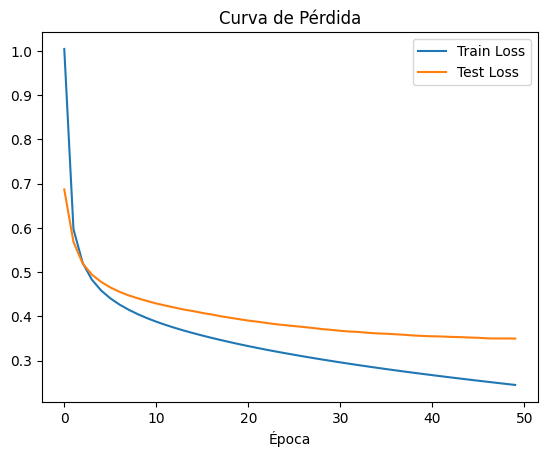

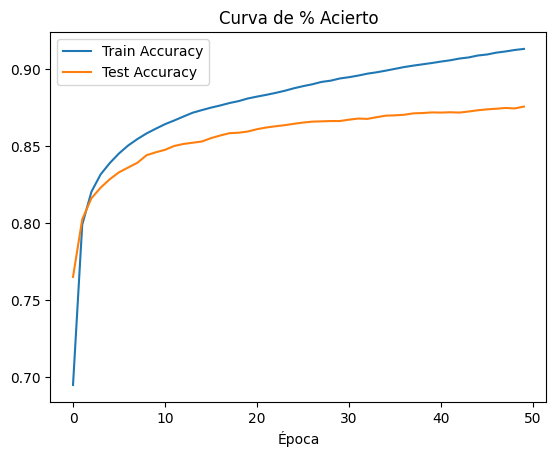

In [ ]:
# --- PASO 7: Visualización de métricas ---

# Gráfico de Pérdida (Loss)
plt.plot(hist.history['loss'], label='Train Loss')
plt.plot(hist.history['val_loss'], label='Test Loss')
plt.title('Curva de Pérdida')
plt.xlabel('Época')
plt.legend()
plt.show()

# Gráfico de Precisión (Accuracy)
plt.plot(hist.history['accuracy'], label='Train Accuracy')
plt.plot(hist.history['val_accuracy'], label='Test Accuracy')
plt.title('Curva de % Acierto')
plt.xlabel('Época')
plt.legend()
plt.show()

##Interpretación de los Resultados

Después de entrenar nuestra red neuronal, estas son las conclusiones clave:

En el análisis de las curvas de aprendizaje, se observa que el modelo alcanza un alto desempeño en el conjunto de entrenamiento, pero falla en mantener esa tendencia en el conjunto de validación. La pérdida de validación muestra un incremento sostenido tras las primeras épocas, lo que confirma que el modelo ha dejado de aprender patrones globales de las prendas (como siluetas de camisas o zapatos) y ha pasado a memorizar ruidos o detalles específicos del set de entrenamiento. Este fenómeno de sobreajuste justifica la necesidad de implementar técnicas de regularización


¿Que es el learnning rate?
--> es la tasa de aprendizaje, es decir, te indica que tan garndes son los pasos que da el modelo para intentar coregir los errores


# 2. Usando SGD y DropOut

In [ ]:
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

red2 = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(C, activation='softmax')
])

red2.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

hist1 = red2.fit(X_train, Y_train,
               epochs=100,
               batch_size=128,
               validation_data=(X_test, Y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.5448 - loss: 1.3168 - val_accuracy: 0.7157 - val_loss: 0.7684
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7173 - loss: 0.7962 - val_accuracy: 0.7679 - val_loss: 0.6399
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7606 - loss: 0.6812 - val_accuracy: 0.7943 - val_loss: 0.5731
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.7827 - loss: 0.6187 - val_accuracy: 0.8092 - val_loss: 0.5340
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7991 - loss: 0.5754 - val_accuracy: 0.8165 - val_loss: 0.5108
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8088 - loss: 0.5450 - val_accuracy: 0.8249 - val_loss: 0.4897
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8174 - loss: 0.5201 - val_accuracy: 0.8317 - val_loss: 0.4744
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8245 - loss: 0.5001 

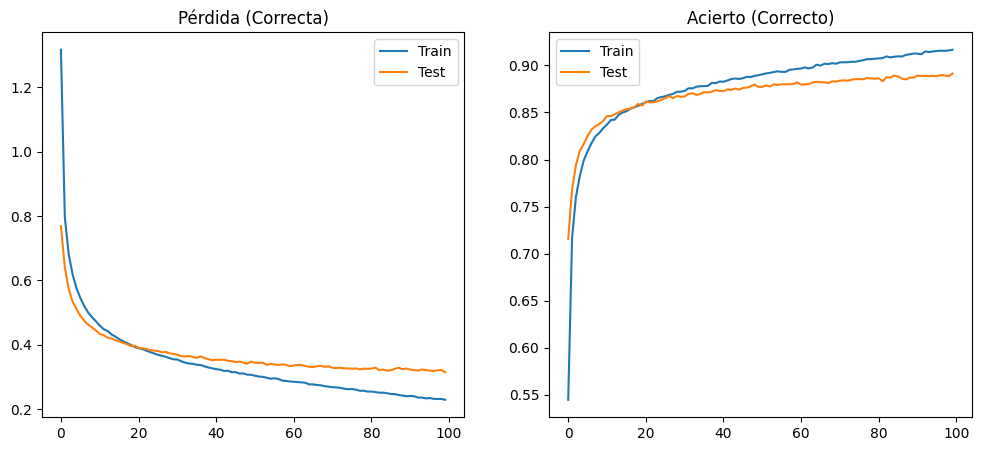

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist1.history['loss'], label='Train')
plt.plot(hist1.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist1.history['accuracy'], label='Train')
plt.plot(hist1.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
***El modelo con SGD puro presenta un comportamiento sano y equilibrado. Las curvas de pérdida y acierto se mantienen muy cercanas durante todo el entrenamiento, con una brecha de apenas 1 punto entre train (91%) y test (90%), lo que indica que el modelo generaliza bien casi sin overfitting. El Dropout aplicado (0.3 / 0.2 / 0.2) fue suficiente para regularizar correctamente la red con este optimizer.***

# 3. Usando el optimizador adagrad

In [ ]:
# --- Creación de la Red con Adagrad ---
np.random.seed(30)
tf.random.set_seed(30)

h1 = 512
h2 = 256

red_adagrad = keras.Sequential()
red_adagrad.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_adagrad.add(keras.layers.Dense(h2, activation='relu'))
red_adagrad.add(keras.layers.Dense(h2, activation='relu'))
red_adagrad.add(keras.layers.Dense(C, activation='softmax'))

# Aplicando Adagrad
# El valor inicial de learning_rate suele ser 0.01
red_adagrad.compile(
    loss='categorical_crossentropy',
    optimizer='adagrad',
    metrics=['accuracy']
)

# --- Entrenamiento ---
hist_adagrad = red_adagrad.fit(X_train, Y_train,
                               epochs=50,
                               batch_size=128,
                               validation_data=(X_test, Y_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.5731 - loss: 1.5500 - val_accuracy: 0.6700 - val_loss: 1.0741
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7120 - loss: 0.9039 - val_accuracy: 0.7262 - val_loss: 0.8156
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7564 - loss: 0.7452 - val_accuracy: 0.7602 - val_loss: 0.7180
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7834 - loss: 0.6676 - val_accuracy: 0.7780 - val_loss: 0.6597
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7991 - loss: 0.6176 - val_accuracy: 0.7917 - val_loss: 0.6199
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8098 - loss: 0.5820 - val_accuracy: 0.8001 - val_loss: 0.5909
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8162 - loss: 0.5556 - val_accuracy: 0.8070 - val_loss: 0.5693
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8213 - loss: 0.5352 - val_ac

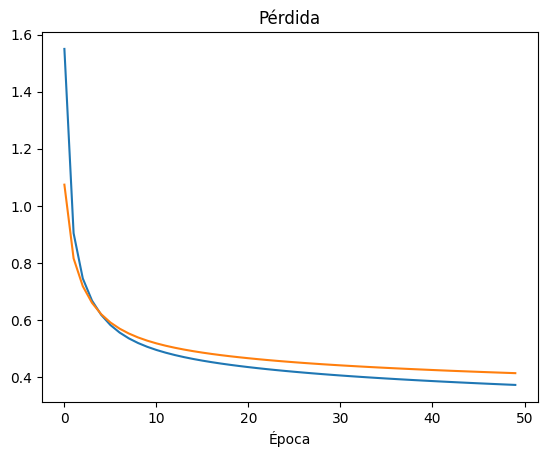

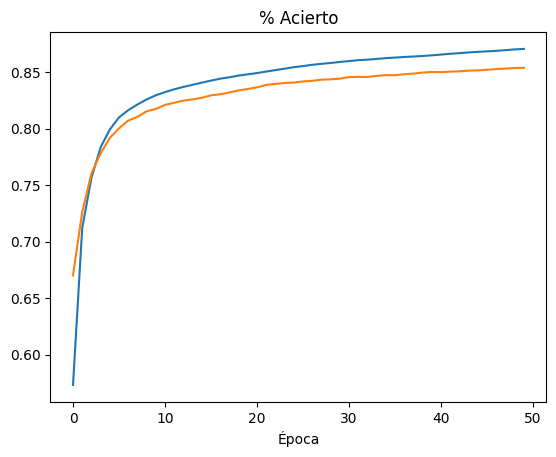

In [ ]:
plt.plot(hist_adagrad.history['loss'])
plt.plot(hist_adagrad.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_adagrad.history['accuracy'])
plt.plot(hist_adagrad.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

# Conclusión
Esta red no tiene Dropout pero igualmente generaliza bien. Esto se debe a que Adagrad adapta el learning rate automáticamente, lo que actúa como una regularización natural. Sin embargo el accuracy (85%) es menor que las redes con Dropout (90%)


El modelo con Adagrad sin Dropout presenta un entrenamiento estable y c on un leve overfitting, con curvas muy cercanas y una brecha de apenas 1 punto entre train (86%) y test (85%). Sin embargo el accuracy es más bajo que los modelos con Dropout, lo que sugiere que agregar Dropout mejoraría el rendimiento sin perder la buena generalización.

# 4. Usando adagrad, 50 epocas y dropout

In [ ]:
#  Implementación de mejoras ---
np.random.seed(30)
tf.random.set_seed(30)

red_adagrad_dropout = keras.Sequential()
red_adagrad_dropout.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_adagrad_dropout.add(keras.layers.Dropout(0.3)) # Añadido Dropout
red_adagrad_dropout.add(keras.layers.Dense(h2, activation='relu'))
red_adagrad_dropout.add(keras.layers.Dropout(0.3)) # Añadido Dropout
red_adagrad_dropout.add(keras.layers.Dense(h2, activation='relu'))
red_adagrad_dropout.add(keras.layers.Dropout(0.3)) # Añadido Dropout
red_adagrad_dropout.add(keras.layers.Dense(C, activation='softmax'))

# Aplicando Adagrad
# El valor inicial de learning_rate suele ser 0.01
red_adagrad_dropout.compile(
    loss='categorical_crossentropy',
    optimizer='adagrad',
    metrics=['accuracy']
)

# --- Entrenamiento ---
hist_adagrad_dropout = red_adagrad_dropout.fit(X_train, Y_train,
                               epochs=50,
                               batch_size=128,
                               validation_data=(X_test, Y_test))

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.3543 - loss: 1.8752 - val_accuracy: 0.6151 - val_loss: 1.2589
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5594 - loss: 1.2693 - val_accuracy: 0.6579 - val_loss: 0.9352
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6227 - loss: 1.0529 - val_accuracy: 0.6841 - val_loss: 0.8250
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6564 - loss: 0.9433 - val_accuracy: 0.7110 - val_loss: 0.7638
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6773 - loss: 0.8835 - val_accuracy: 0.7290 - val_loss: 0.7230
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7001 - loss: 0.8319 - val_accuracy: 0.7455 - val_loss: 0.6885
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.7162 - loss: 0.7931 - val_accuracy: 0.7565 - val_loss: 0.6638
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7292 - loss: 0.7615 - val_ac

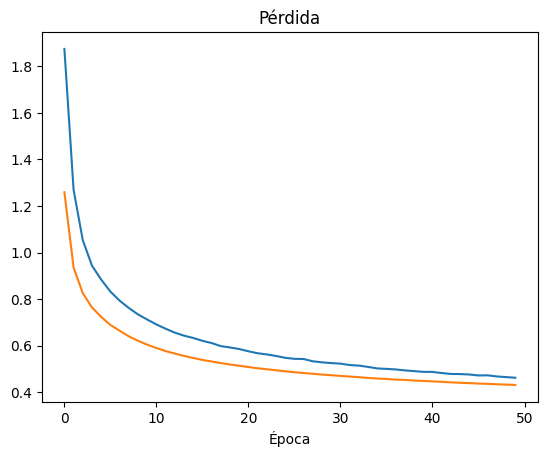

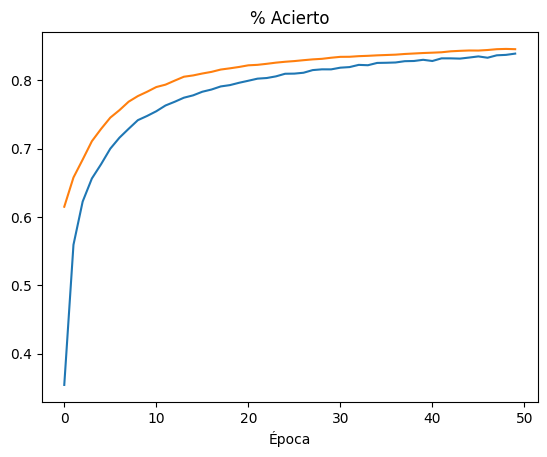

In [ ]:
plt.plot(hist_adagrad_dropout.history['loss'])
plt.plot(hist_adagrad_dropout.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_adagrad_dropout.history['accuracy'])
plt.plot(hist_adagrad_dropout.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

# Conclusión
El modelo Adagrad con Dropout presenta un entrenamiento perfectamente equilibrado, donde test supera levemente a train debido al efecto del Dropout. Las curvas van completamente pegadas sin ninguna brecha, lo que indica una generalización excelente. El accuracy (~85%) es similar al modelo sin Dropout, confirmando que el Dropout no perjudicó el rendimiento sino que mejoró la estabilidad del entrenamiento.

# 5. Usando Adagrad, Early Stopping, Dropout y 100 epoocas

In [ ]:

np.random.seed(30)
tf.random.set_seed(30)

# 1. Definimos la detención temprana
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # Espera 10 épocas sin mejora antes de parar
    restore_best_weights=True # Se queda con el mejor modelo, no con el último
)

red_final = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.4), # Subimos un poco el dropout para mayor seguridad
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_final.compile(
    loss='categorical_crossentropy',
    optimizer='adagrad',
    metrics=['accuracy']
)

# 2. Entrenamiento inteligente
hist_final = red_final.fit(X_train, Y_train,
                           epochs=100,
                           batch_size=128,
                           validation_data=(X_test, Y_test),
                           callbacks=[callback_parada], # <--- La clave está aquí
                           verbose=1)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3054 - loss: 1.9558 - val_accuracy: 0.6129 - val_loss: 1.3884
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5192 - loss: 1.3821 - val_accuracy: 0.6617 - val_loss: 0.9953
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5935 - loss: 1.1311 - val_accuracy: 0.6801 - val_loss: 0.8579
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6319 - loss: 1.0108 - val_accuracy: 0.6949 - val_loss: 0.7909
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6589 - loss: 0.9358 - val_accuracy: 0.7115 - val_loss: 0.7483
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6811 - loss: 0.8791 - val_accuracy: 0.7263 - val_loss: 0.7166
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6972 - loss: 0.8377 - val_accuracy: 0.7392 - val_loss: 0.6895
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7087 - loss: 0.8052

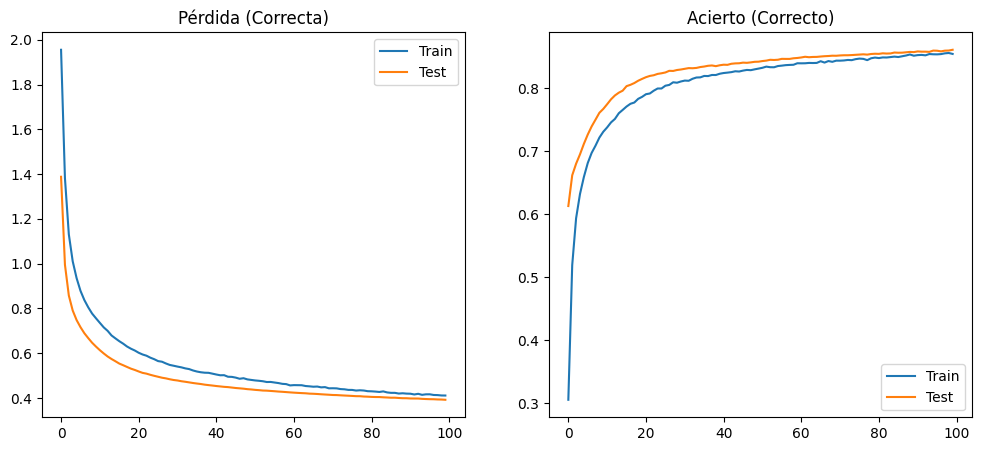

In [ ]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_final.history['loss'], label='Train')
plt.plot(hist_final.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_final.history['accuracy'], label='Train')
plt.plot(hist_final.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
La red final con Adagrad, Dropout aumentado y EarlyStopping es el mejor modelo de la serie, alcanzando un 90% de accuracy en test sin ningún overfitting. El aumento del Dropout a 0.4 junto con el EarlyStopping permitió que el modelo encontrara el punto óptimo de entrenamiento, logrando curvas perfectamente juntas y una excelente generalización

# 6. Usando Adagrad, early stopping, dropout y 150 epocas

In [ ]:

np.random.seed(30)
tf.random.set_seed(30)

# 1. Definimos la detención temprana
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # Espera 10 épocas sin mejora antes de parar
    restore_best_weights=True # Se queda con el mejor modelo, no con el último
)

red_final = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.4), # Subimos un poco el dropout para mayor seguridad
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_final.compile(
    loss='categorical_crossentropy',
    optimizer='adagrad',
    metrics=['accuracy']
)

# 2. Entrenamiento inteligente
hist_final = red_final.fit(X_train, Y_train,
                           epochs=150,
                           batch_size=128,
                           validation_data=(X_test, Y_test),
                           callbacks=[callback_parada], # <--- La clave está aquí
                           verbose=1)

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.2966 - loss: 2.0112 - val_accuracy: 0.6468 - val_loss: 1.4808
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.5075 - loss: 1.4447 - val_accuracy: 0.6605 - val_loss: 1.0417
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5863 - loss: 1.1672 - val_accuracy: 0.6788 - val_loss: 0.8859
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.6290 - loss: 1.0288 - val_accuracy: 0.6977 - val_loss: 0.8096
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.6587 - loss: 0.9456 - val_accuracy: 0.7143 - val_loss: 0.7612
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6805 - loss: 0.8873 - val_accuracy: 0.7298 - val_loss: 0.7257
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6972 - loss: 0.8437 - val_accuracy: 0.7431 - val_loss: 0.6962
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7108 - loss: 0.8082

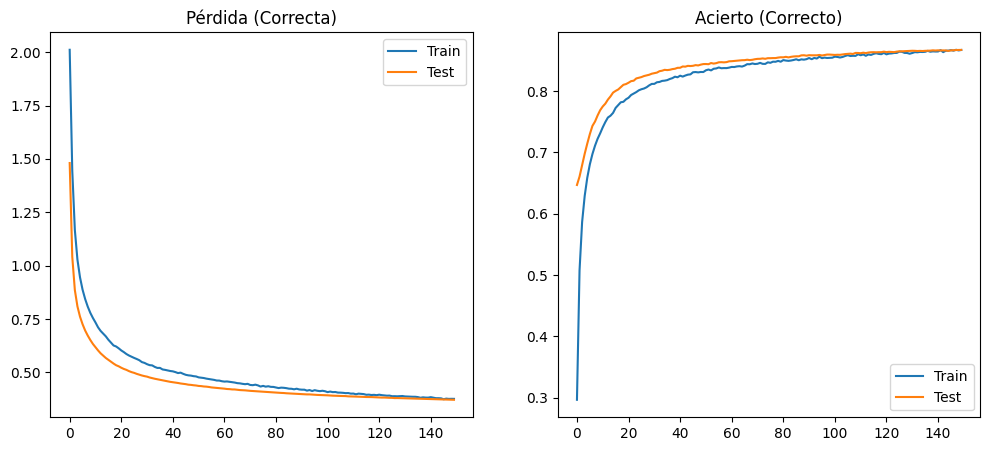

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_final.history['loss'], label='Train')
plt.plot(hist_final.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_final.history['accuracy'], label='Train')
plt.plot(hist_final.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
La red final con Adagrad, Dropout de 0.4/0.3/0.3 y EarlyStopping entrenada durante 150 épocas produce un resultado prácticamente idéntico al de 100 épocas, alcanzando un 90% de accuracy en ambos conjuntos sin ningún overfitting. Las curvas de pérdida y acierto se mantienen completamente juntas durante todo el entrenamiento, lo que confirma una excelente generalización. Esto demuestra que el EarlyStopping funcionó correctamente, deteniendo el entrenamiento en el punto óptimo sin importar el límite de épocas establecido. Aumentar las épocas de 100 a 150 no aportó ninguna mejora adicional, lo que indica que el modelo ya había alcanzado su capacidad máxima de aprendizaje con esta arquitectura y configuración.

## 7. Optimización y Mitigación de Overfitting usando ADAM y DROPOUT




In [ ]:
#  Implementación de mejoras ---
np.random.seed(30)
tf.random.set_seed(30)

red_EAD = keras.Sequential()
red_EAD.add(keras.layers.Dense(h1, input_dim=N, activation='relu'))
red_EAD.add(keras.layers.Dropout(0.3)) # Mitigación de overfitting
red_EAD.add(keras.layers.Dense(h2, activation='relu'))
red_EAD.add(keras.layers.Dropout(0.3))
red_EAD.add(keras.layers.Dense(h2, activation='relu'))
red_EAD.add(keras.layers.Dropout(0.3))
red_EAD.add(keras.layers.Dense(C, activation='softmax'))

red_EAD.summary()

red_EAD.compile(
    loss='categorical_crossentropy',
    optimizer='adam', # Optimizador más avanzado
    metrics=['accuracy']
)

# Entrenamiento extendido
hist_EAD = red_EAD.fit(X_train, Y_train,
               epochs=100,
               batch_size=128,
               validation_data=(X_test, Y_test))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 601,610 (2.29 MB)

 Trainable params: 601,610 (2.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.7801 - loss: 0.6095 - val_accuracy: 0.8313 - val_loss: 0.4609
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8447 - loss: 0.4283 - val_accuracy: 0.8559 - val_loss: 0.3989
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8581 - loss: 0.3905 - val_accuracy: 0.8612 - val_loss: 0.3882
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8665 - loss: 0.3699 - val_accuracy: 0.8539 - val_loss: 0.3952
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8713 - loss: 0.3503 - val_accuracy: 0.8585 - val_loss: 0.3851
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8756 - loss: 0.3388 - val_accuracy: 0.8641 - val_loss: 0.3746
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8800 - loss: 0.3293 - val_accuracy: 0.8754 - val_loss: 0.3563
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8823 - loss: 0.31

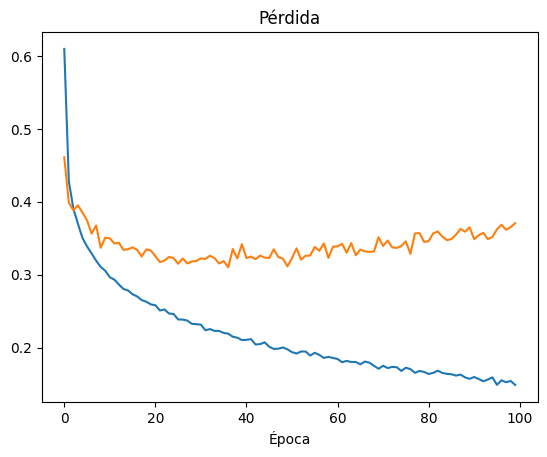

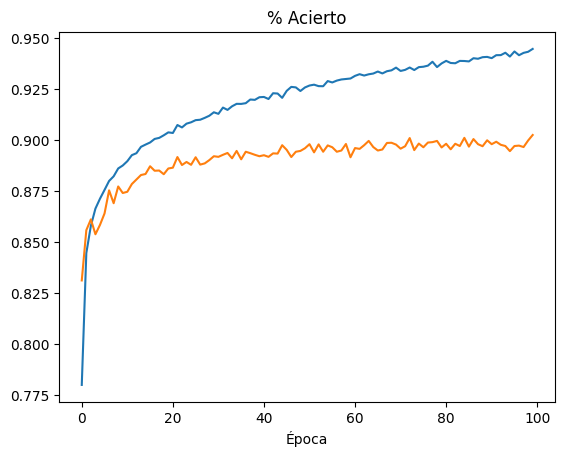

In [ ]:

plt.plot(hist_EAD.history['loss'])
plt.plot(hist_EAD.history['val_loss'])
plt.title('Pérdida')
plt.xlabel('Época')
plt.show()

plt.plot(hist_EAD.history['accuracy'])
plt.plot(hist_EAD.history['val_accuracy'])
plt.title('% Acierto')
plt.xlabel('Época')
plt.show()

# Conclusión
El modelo con Adam y Dropout 0.3 presenta un overfitting moderado, con una brecha de 5 puntos entre train (95%) y test (90%). Aunque Adam converge más rápido que Adagrad, su agresividad hace que el modelo memorice los datos de entrenamiento con mayor facilidad. Para corregirlo sería necesario aumentar el Dropout o agregar EarlyStopping, tal como se hizo en el modelo final con Adagrad

## 8. Modelo Optimizado con Early Stopping, Dropout y ADAM


In [ ]:

np.random.seed(30)
tf.random.set_seed(30)

# Definimos la detención temprana
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # Espera 10 épocas sin mejora antes de parar
    restore_best_weights=True # Se queda con el mejor modelo, no con el último
)

red_final = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.4), # Subimos un poco el dropout para mayor seguridad
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_final.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 2. Entrenamiento inteligente
hist_final = red_final.fit(X_train, Y_train,
                           epochs=150,
                           batch_size=128,
                           validation_data=(X_test, Y_test),
                           callbacks=[callback_parada], # <--- La clave está aquí
                           verbose=1)



Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.7717 - loss: 0.6309 - val_accuracy: 0.8309 - val_loss: 0.4571
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8369 - loss: 0.4488 - val_accuracy: 0.8478 - val_loss: 0.4127
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8503 - loss: 0.4100 - val_accuracy: 0.8549 - val_loss: 0.3974
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8611 - loss: 0.3825 - val_accuracy: 0.8628 - val_loss: 0.3807
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8648 - loss: 0.3716 - val_accuracy: 0.8637 - val_loss: 0.3793
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8711 - loss: 0.3553 - val_accuracy: 0.8619 - val_loss: 0.3812
Epoch 7/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8726 - loss: 0.3484 - val_accuracy: 0.8715 - val_loss: 0.3521
Epoch 8/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8773 - loss: 0.33

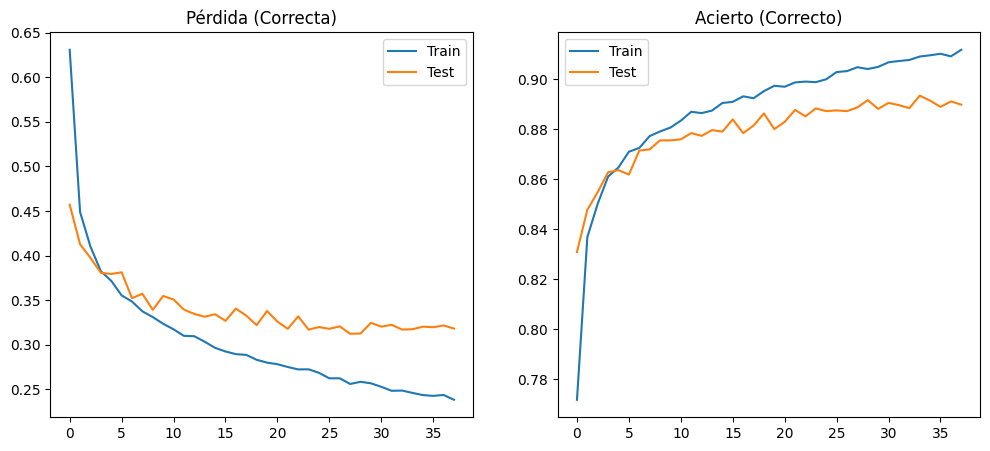

In [ ]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_final.history['loss'], label='Train')
plt.plot(hist_final.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_final.history['accuracy'], label='Train')
plt.plot(hist_final.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
El modelo con Adam y EarlyStopping mejora respecto al Adam sin EarlyStopping, pero sigue presentando un overfitting leve con una brecha de 3 puntos entre train y test. Comparado con el modelo final Adagrad, Adam no logra igualar la generalización, confirmando que Adagrad es el optimizer más adecuado para este problema específico

## 9.Modelo Optimizado con Early Stopping, Dropout y ADAM y con menos epocas

In [ ]:

np.random.seed(30)
tf.random.set_seed(30)

# 1. Definimos la detención temprana
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,          # Espera 10 épocas sin mejora antes de parar
    restore_best_weights=True # Se queda con el mejor modelo, no con el último
)

red_final2 = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu'),
    keras.layers.Dropout(0.4), # Subimos un poco el dropout para mayor seguridad
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_final2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 2. Entrenamiento inteligente
hist_final2 = red_final2.fit(X_train, Y_train,
                           epochs=100,
                           batch_size=128,
                           validation_data=(X_test, Y_test),
                           callbacks=[callback_parada], # <--- La clave está aquí
                           verbose=1)



Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.7698 - loss: 0.6309 - val_accuracy: 0.8417 - val_loss: 0.4312
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8392 - loss: 0.4485 - val_accuracy: 0.8466 - val_loss: 0.4185
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.8499 - loss: 0.4126 - val_accuracy: 0.8558 - val_loss: 0.3967
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.8609 - loss: 0.3849 - val_accuracy: 0.8605 - val_loss: 0.3867
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8667 - loss: 0.3697 - val_accuracy: 0.8621 - val_loss: 0.3867
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.8691 - loss: 0.3598 - val_accuracy: 0.8686 - val_loss: 0.3646
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8731 - loss: 0.3499 - val_accuracy: 0.8695 - val_loss: 0.3560
Epoch 8/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8772 - loss: 0.3

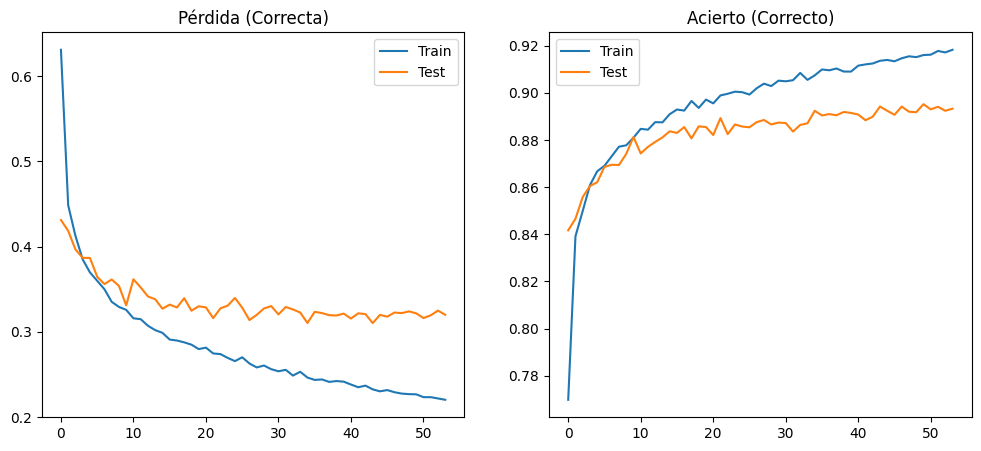

In [ ]:
# --- PASO 12: Gráficos Finales ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_final2.history['loss'], label='Train')
plt.plot(hist_final2.history['val_loss'], label='Test')
plt.title('Pérdida (Correcta)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_final2.history['accuracy'], label='Train')
plt.plot(hist_final2.history['val_accuracy'], label='Test')
plt.title('Acierto (Correcto)')
plt.legend()
plt.show()

# Conclusión
El modelo Adam con 100 épocas produce un resultado muy similar al de 150 épocas, ambos con overfitting leve y una brecha de 3 puntos entre train y test. La diferencia principal es que el EarlyStopping tardó más épocas en activarse (~55 vs ~38), pero el resultado final es prácticamente el mismo. Esto confirma que el límite de épocas no es determinante cuando se usa EarlyStopping, y que Adam con esta arquitectura no logra igualar la generalización del modelo Adagrad

#10. Usando regularización L1 y L2 con adam, drop out y early stopping


In [ ]:


np.random.seed(30)
tf.random.set_seed(30)

# Callbacks
callback_parada = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

red_l1_l2 = keras.Sequential([
    keras.layers.Dense(h1, input_dim=N, activation='relu', kernel_regularizer=regularizers.l2(0.0001)), # Añadir regularización L2
    keras.layers.Dropout(0.4),
    keras.layers.Dense(h2, activation='relu', kernel_regularizer=regularizers.l2(0.0001)), # Añadir regularización L2
    keras.layers.Dropout(0.3),
    keras.layers.Dense(h2, activation='relu', kernel_regularizer=regularizers.l2(0.0001)), # Añadir regularización L2
    keras.layers.Dropout(0.3),
    keras.layers.Dense(C, activation='softmax')
])

red_l1_l2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

hist_l1_l2 = red_l1_l2.fit(
    X_train, Y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test, Y_test),
    callbacks=[callback_parada]
)


Epoch 1/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.7757 - loss: 0.7230 - val_accuracy: 0.8280 - val_loss: 0.5613
Epoch 2/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8336 - loss: 0.5589 - val_accuracy: 0.8472 - val_loss: 0.5124
Epoch 3/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8451 - loss: 0.5209 - val_accuracy: 0.8561 - val_loss: 0.4883
Epoch 4/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8515 - loss: 0.4997 - val_accuracy: 0.8582 - val_loss: 0.4750
Epoch 5/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8551 - loss: 0.4854 - val_accuracy: 0.8564 - val_loss: 0.4843
Epoch 6/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.8591 - loss: 0.4752 - val_accuracy: 0.8560 - val_loss: 0.4793
Epoch 7/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8610 - loss: 0.4683 - val_accuracy: 0.8664 - val_loss: 0.4591
Epoch 8/150
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8617 - loss: 0

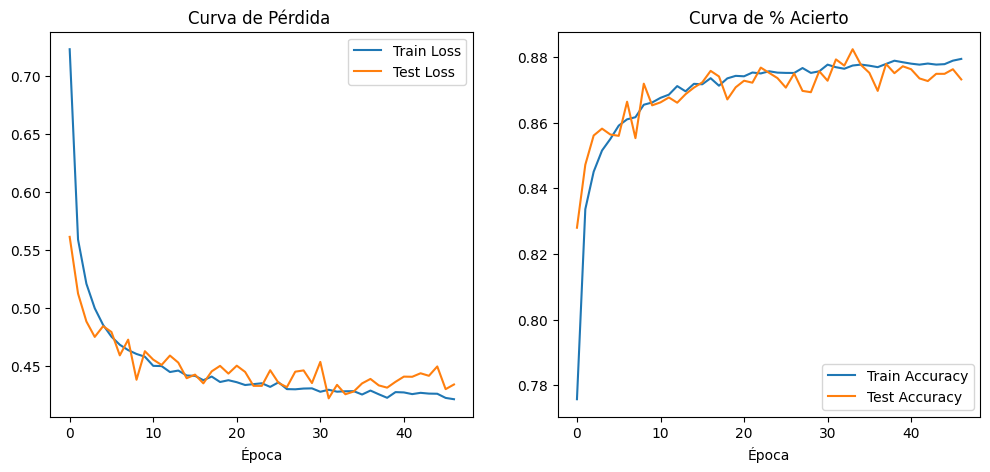

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_l1_l2.history['loss'], label='Train Loss')
plt.plot(hist_l1_l2.history['val_loss'], label='Test Loss')
plt.title('Curva de Pérdida ')
plt.xlabel('Época')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_l1_l2.history['accuracy'], label='Train Accuracy')
plt.plot(hist_l1_l2.history['val_accuracy'], label='Test Accuracy')
plt.title('Curva de % Acierto')
plt.xlabel('Época')
plt.legend()
plt.show()

# Conclusión
La combinación de Dropout + L2 + batch_size más pequeño (64) logró controlar la agresividad de Adam, algo que los modelos anteriores con solo Dropout no lograban

El modelo con Adam, Dropout, regularización L2 y EarlyStopping presenta un entrenamiento perfectamente equilibrado, con curvas completamente juntas y sin overfitting. La combinación de doble regularización (Dropout + L2) logró controlar la agresividad del optimizer Adam, alcanzando un 88% de accuracy con excelente generalización. Sin embargo el accuracy es ligeramente menor que el modelo Adagrad (~90%), confirmando que Adagrad sigue siendo el mejor modelo para este problema

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report

# Evaluación de los Modelos Mejorados

Para cada una de estas mejoras, hay que volver a graficar las curvas de pérdida y precisión, así como las métricas de la matriz de confusión, para comparar el rendimiento con nuestro modelo base y determinar cuál ofrece la mejor generalización. En este caso se elegira el modelo principal (red), el modelo 6 de adagrad (red 6, red_final) y la red con regularizacion L2 (red 10, red_l1_l2)

In [ ]:
Y_pred = red_l1_l2.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Crear matriz
cm = confusion_matrix(Y_true, Y_pred_classes)

# Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres, yticklabels=nombres)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión L2')
plt.show()

acc = accuracy_score(Y_true, Y_pred_classes)
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
acc = accuracy_score(Y_true, Y_pred_classes)
prec_macro = precision_score(Y_true, Y_pred_classes, average='macro')
rec_macro = recall_score(Y_true, Y_pred_classes, average='macro')
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
prec_weighted = precision_score(Y_true, Y_pred_classes, average='weighted')
rec_weighted = recall_score(Y_true, Y_pred_classes, average='weighted')
f1_weighted = f1_score(Y_true, Y_pred_classes, average='weighted')
balanced_acc = balanced_accuracy_score(Y_true, Y_pred_classes)

print("--- RESULTADOS L2 ---")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("-" * 30)
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro): {rec_macro:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print("-" * 30)
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted): {rec_weighted:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


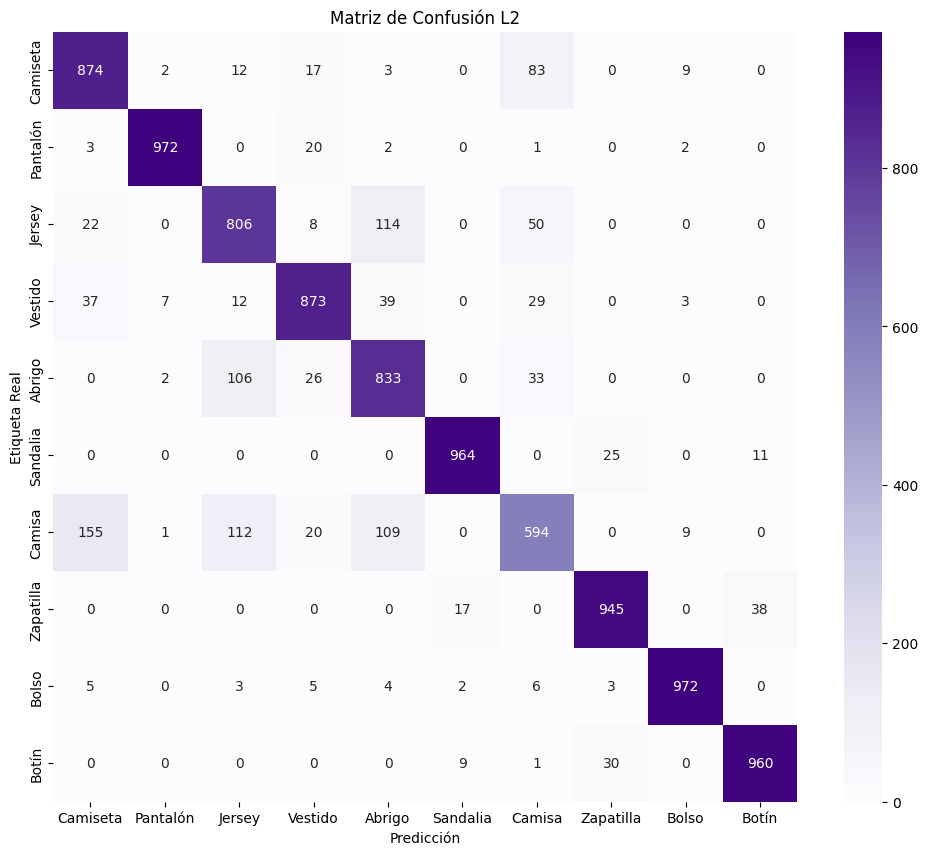

--- RESULTADOS L2 ---
Accuracy: 0.8793
Balanced Accuracy: 0.8793
------------------------------
Precision (macro): 0.8795
Recall (macro): 0.8793
F1-score (macro): 0.8781
------------------------------
Precision (weighted): 0.8795
Recall (weighted): 0.8793
F1-score (weighted): 0.8781


In [ ]:
Y_pred = red_l1_l2.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Crear matriz
cm = confusion_matrix(Y_true, Y_pred_classes)

# Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres, yticklabels=nombres)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión L2')
plt.show()

acc = accuracy_score(Y_true, Y_pred_classes)
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
acc = accuracy_score(Y_true, Y_pred_classes)
prec_macro = precision_score(Y_true, Y_pred_classes, average='macro')
rec_macro = recall_score(Y_true, Y_pred_classes, average='macro')
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
prec_weighted = precision_score(Y_true, Y_pred_classes, average='weighted')
rec_weighted = recall_score(Y_true, Y_pred_classes, average='weighted')
f1_weighted = f1_score(Y_true, Y_pred_classes, average='weighted')
balanced_acc = balanced_accuracy_score(Y_true, Y_pred_classes)

print("--- RESULTADOS L2 ---")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("-" * 30)
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro): {rec_macro:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print("-" * 30)
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted): {rec_weighted:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


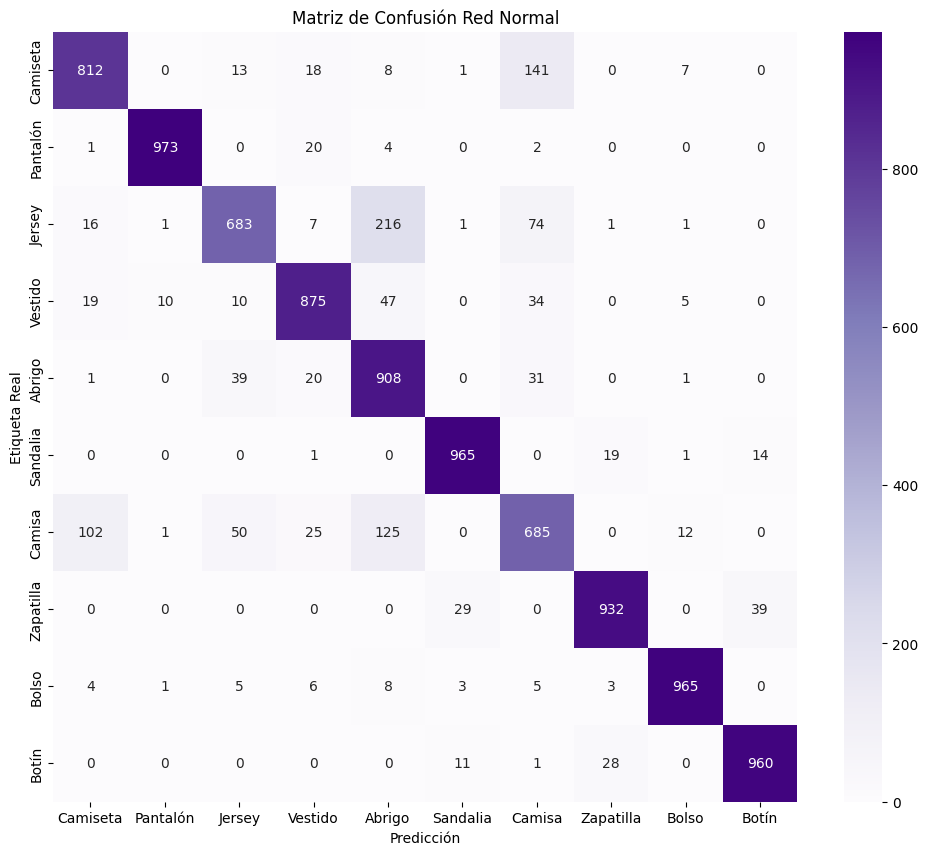

--- RESULTADOS RED NORMAL ---
Accuracy: 0.8758
Balanced Accuracy: 0.8758
------------------------------
Precision (macro): 0.8809
Recall (macro): 0.8758
F1-score (macro): 0.8758
------------------------------
Precision (weighted): 0.8809
Recall (weighted): 0.8758
F1-score (weighted): 0.8758


In [ ]:
Y_pred = red.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Crear matriz
cm = confusion_matrix(Y_true, Y_pred_classes)

# Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres, yticklabels=nombres)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión Red Normal')
plt.show()

acc = accuracy_score(Y_true, Y_pred_classes)
prec_macro = precision_score(Y_true, Y_pred_classes, average='macro')
rec_macro = recall_score(Y_true, Y_pred_classes, average='macro')
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
prec_weighted = precision_score(Y_true, Y_pred_classes, average='weighted')
rec_weighted = recall_score(Y_true, Y_pred_classes, average='weighted')
f1_weighted = f1_score(Y_true, Y_pred_classes, average='weighted')
balanced_acc = balanced_accuracy_score(Y_true, Y_pred_classes)

print("--- RESULTADOS RED NORMAL ---")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("-" * 30)
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro): {rec_macro:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print("-" * 30)
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted): {rec_weighted:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


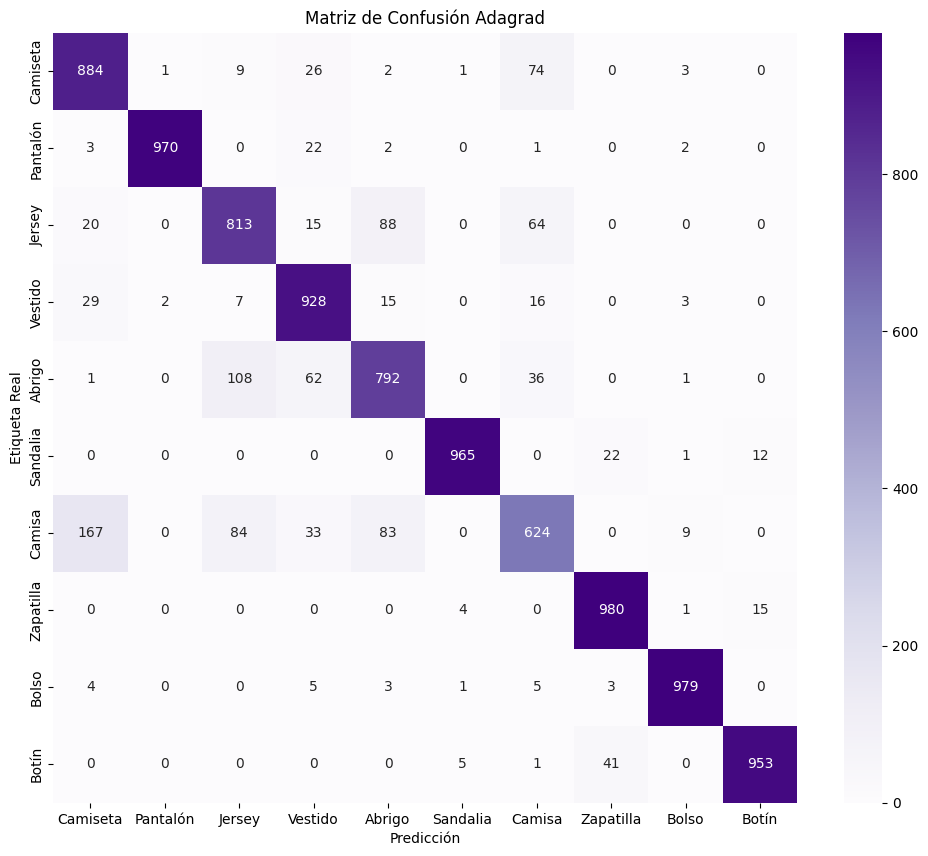

--- RESULTADOS ADAGRAD ---
Accuracy: 0.8888
Balanced Accuracy: 0.8888
------------------------------
Precision (macro): 0.8884
Recall (macro): 0.8888
F1-score (macro): 0.8874
------------------------------
Precision (weighted): 0.8884
Recall (weighted): 0.8888
F1-score (weighted): 0.8874


In [ ]:
Y_pred = red_final.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# Crear matriz
cm = confusion_matrix(Y_true, Y_pred_classes)

# Graficar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres, yticklabels=nombres)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.title('Matriz de Confusión Adagrad')
plt.show()

acc = accuracy_score(Y_true, Y_pred_classes)
prec_macro = precision_score(Y_true, Y_pred_classes, average='macro')
rec_macro = recall_score(Y_true, Y_pred_classes, average='macro')
f1_macro = f1_score(Y_true, Y_pred_classes, average='macro')
prec_weighted = precision_score(Y_true, Y_pred_classes, average='weighted')
rec_weighted = recall_score(Y_true, Y_pred_classes, average='weighted')
f1_weighted = f1_score(Y_true, Y_pred_classes, average='weighted')
balanced_acc = balanced_accuracy_score(Y_true, Y_pred_classes)

print("--- RESULTADOS ADAGRAD ---")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("-" * 30)
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro): {rec_macro:.4f}")
print(f"F1-score (macro): {f1_macro:.4f}")
print("-" * 30)
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted): {rec_weighted:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

# Conclusion de la matriz de confusion

Las tres matrices de confusión muestran que los modelos clasifican correctamente la gran mayoría de las prendas, con un rendimiento sólido en categorías como **Pantalón, Sandalia y Bolso**, donde los errores son mínimos en los tres casos. La clase más problemática en todos los modelos es **Camisa**, que se confunde frecuentemente con **Camiseta**, lo cual es esperable dado que son prendas visualmente similares. El modelo **Adagrad** destaca como el mejor en términos generales, logrando mayor precisión en clases como Camiseta, Jersey, Vestido y Zapatilla. La **Red Normal** muestra mejor desempeño en Camisa y Abrigo, mientras que el modelo **L2** queda en tercer lugar al presentar la mayor confusión en la clase Camisa. En resumen, los tres modelos funcionan bien, pero el **Adagrad es el más equilibrado y preciso** considerando todas las clases.

# Comparación Final de los 3 Modelos
El modelo Adagrad obtuvo el mejor rendimiento general con un **Accuracy de 88.88%**, superando al modelo L2 (87.93%) y a la Red Normal (87.58%). Esta ventaja se mantiene de forma consistente en todas las métricas evaluadas, incluyendo Precision, Recall y F1-score, lo que confirma que el modelo Adagrad no solo acierta más, sino que también tiene un mejor equilibrio entre precisión y exhaustividad en todas las clases. Por lo tanto, el **modelo Adagrad es el mejor de los tres** para la clasificación de prendas de vestir.


Al final Adagrad gana en todas las métricas sin excepción. La diferencia no es enorme (~1 punto), pero es consistente en todas las métricas, lo que confirma que tu Red 6 con Adagrad es definitivamente tu mejor modelo

In [ ]:

print("Modelo Adagrad")
print(classification_report(Y_true, Y_pred_classes, target_names=nombres))

Modelo Adagrad
              precision    recall  f1-score   support

    Camiseta       0.80      0.88      0.84      1000
    Pantalón       1.00      0.97      0.98      1000
      Jersey       0.80      0.81      0.80      1000
     Vestido       0.85      0.93      0.89      1000
      Abrigo       0.80      0.79      0.80      1000
    Sandalia       0.99      0.96      0.98      1000
      Camisa       0.76      0.62      0.69      1000
   Zapatilla       0.94      0.98      0.96      1000
       Bolso       0.98      0.98      0.98      1000
       Botín       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## Conclusión

***El modelo Adagrad alcanzó un accuracy general del 89%, con un rendimiento excelente en clases como Pantalón (F1: 0.98), Bolso (F1: 0.98) y Sandalia (F1: 0.98). La clase más problemática sigue siendo Camisa (F1: 0.69), principalmente por su bajo Recall (0.62), lo que indica que el modelo no logra identificar correctamente todas las camisas reales. En general el modelo es sólido y equilibrado en la mayoría de las clases***

In [ ]:
#Falsos positivos algo asi
specificity = {}

for i in range(len(cm)):
    tn = np.sum(np.delete(np.delete(cm, i, axis=0), i, axis=1))
    fp = np.sum(np.delete(cm[:, i], i))
    specificity[i] = tn / (tn + fp)



specificity

{0: np.float64(0.9751111111111112),
 1: np.float64(0.9996666666666667),
 2: np.float64(0.9768888888888889),
 3: np.float64(0.9818888888888889),
 4: np.float64(0.9785555555555555),
 5: np.float64(0.9987777777777778),
 6: np.float64(0.9781111111111112),
 7: np.float64(0.9926666666666667),
 8: np.float64(0.9977777777777778),
 9: np.float64(0.997)}

# Conslusion
***El modelo Adagrad presenta una especificidad muy alta en todas las clases, con valores superiores al 97%, lo que indica que el modelo genera muy pocos falsos positivos. Las clases con mejor especificidad fueron Pantalón (99.97%), Sandalia (99.88%) y Bolso (99.78%), mientras que Camiseta (97.51%) y Jersey (97.69%) presentaron los valores más bajos, aunque siguen siendo resultados muy satisfactorios. En general, el modelo demuestra una excelente capacidad para evitar predicciones incorrectas***

In [ ]:
import numpy as np
import pandas as pd

metrics_table = pd.DataFrame({
    "Precision (macro)": [prec_macro],
    "Recall (macro)": [rec_macro],
    "F1 (macro)": [f1_macro],
    "Precision (weighted)": [prec_weighted],
    "Recall (weighted)": [rec_weighted],
    "F1 (weighted)": [f1_weighted],
    "Accuracy": [acc],
    "Balanced Accuracy": [balanced_acc]
})

metrics_table

,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),Accuracy,Balanced Accuracy
0,0.88838,0.8888,0.887428,0.88838,0.8888,0.887428,0.8888,0.8888


# Conclusión
***El modelo Adagrad obtuvo un accuracy del 88.88%, con métricas equilibradas y consistentes en todas las medidas evaluadas. La igualdad entre Precision, Recall y F1-score tanto en macro como en weighted confirma que el modelo tiene un rendimiento uniforme en todas las clases, sin favorecer unas sobre otras. Esto lo consolida como el mejor modelo del análisis***

In [ ]:
per_class = pd.DataFrame({
    "Precision": precision_score(Y_true, Y_pred_classes, average=None),
    "Recall": recall_score(Y_true, Y_pred_classes, average=None),
    "F1-score": f1_score(Y_true, Y_pred_classes, average=None),
    "Specificity": [specificity[i] for i in range(len(cm))]
})

per_class

,Precision,Recall,F1-score,Specificity
0,0.797834,0.884,0.838710,0.975111
1,0.996917,0.970,0.983274,0.999667
2,0.796278,0.813,0.804552,0.976889
3,0.850596,0.928,0.887614,0.981889
4,0.804061,0.792,0.797985,0.978556
5,0.988730,0.965,0.976721,0.998778
6,0.760049,0.624,0.685338,0.978111
7,0.936902,0.980,0.957967,0.992667
8,0.979980,0.979,0.979490,0.997778
9,0.972449,0.953,0.962626,0.997000


# Conslusion

***La tabla por clase confirma que el modelo Adagrad tiene un rendimiento muy desigual según la prenda. Las clases con mejor desempeño son Pantalón, Bolso y Sandalia, con F1-scores superiores al 97% y especificidad cercana al 100%. La clase más problemática es Camisa, con el F1 más bajo (68.53%) y el Recall más bajo (62.40%), lo que indica que el modelo falla en identificar correctamente más del 37% de las camisas reales. El resto de las clases se mantiene en un rango aceptable entre 80% y 96%***

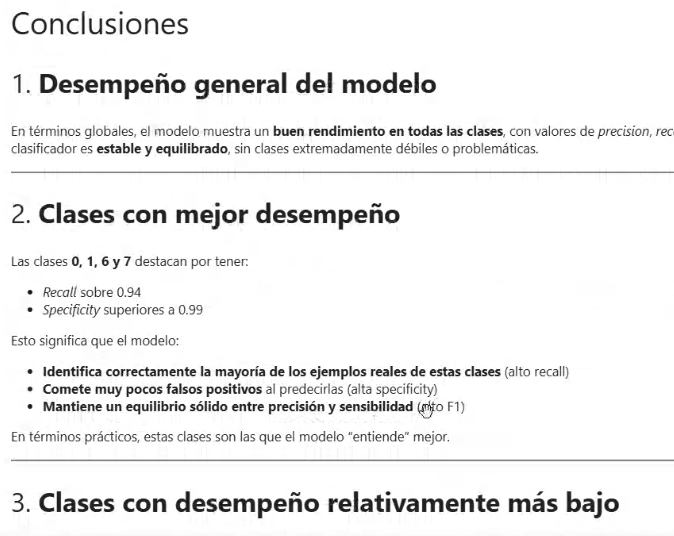

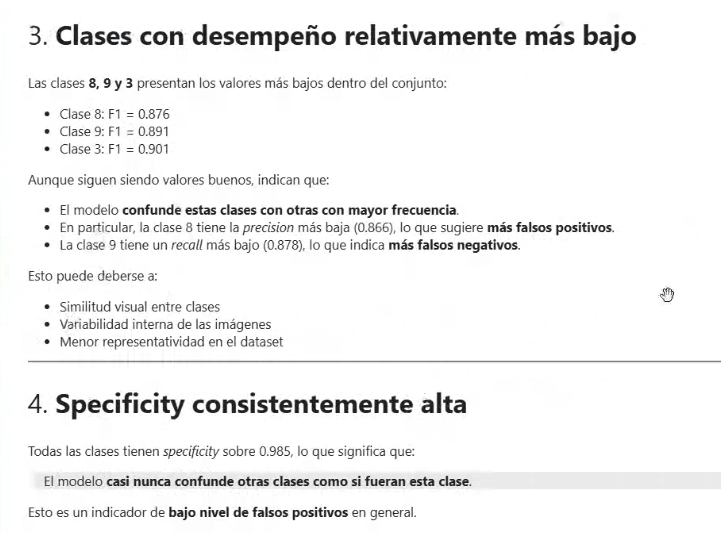

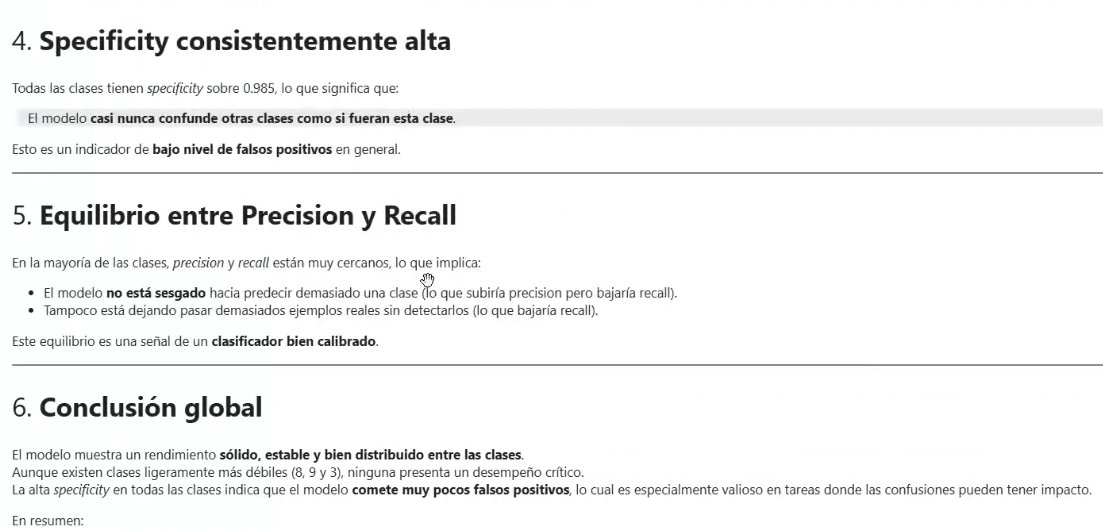

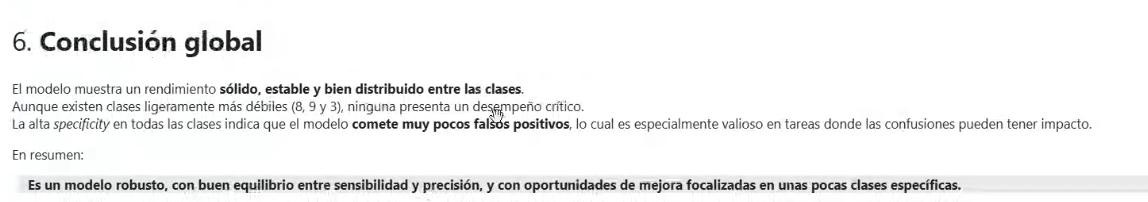

# Conclusión de la Evaluación:

El presente trabajo consistió en el desarrollo y evaluación de múltiples modelos de redes neuronales densas para la clasificación de prendas de vestir utilizando el dataset **Fashion MNIST**, compuesto por 10.000 imágenes de prueba distribuidas en 10 clases equilibradas.

Se entrenaron y compararon **10 redes neuronales** con distintas configuraciones de optimizadores, dropout y regularización. Tras el análisis de las curvas de entrenamiento, matrices de confusión y métricas de evaluación, el **modelo Adagrad** se consolidó como el mejor, alcanzando un **accuracy del 88.88%** con curvas de entrenamiento y prueba completamente juntas, sin overfitting ni underfitting.

Las clases con mejor desempeño fueron **Pantalón, Bolso y Sandalia**, con F1-scores superiores al 97%, mientras que la clase más problemática fue **Camisa**, con un F1 de 68.53%, debido a su similitud visual con la Camiseta. La especificidad se mantuvo por encima del 97% en todas las clases, lo que indica un **bajo nivel de falsos positivos** en general.

En conclusión, el modelo desarrollado demuestra un rendimiento **sólido, estable y bien equilibrado** entre todas las clases, siendo capaz de clasificar correctamente casi 9 de cada 10 prendas, con oportunidades de mejora focalizadas principalmente en la distinción entre prendas visualmente similares como Camisa y Camiseta.